## Customer Segmentation

### Objective

Customer Segmentation is the process of grouping users with similar behavioral patterns into meaningful clusters.

The primary objectives of this notebook are:

- Analyze customer behavior patterns
- Identify distinct customer groups
- Build customer segments using machine learning
- Enable targeted recommendations
- Support personalization strategies

This notebook utilizes K-Means Clustering to create behavioral customer segments based on engineered user features.

The generated customer segments will be used by the Recommendation Engine and Personalization Engine in subsequent stages of the project.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Step 1: Load Engineered Features

Load customer-level behavioral features generated during the Feature Engineering phase.

In [2]:
import os

print(os.getcwd())

D:\PROJECTS\RecommendIQ\notebooks


In [3]:
customer_features = pd.read_csv(
    "../data/features/customer_features.csv"
)

customer_features.head()

,visitorid,total_interactions,total_views,total_cart,total_transactions,unique_items,avg_interaction_strength,recency_days
0,0,3,3.0,0.0,0.0,3,1.0,6
1,1,1,1.0,0.0,0.0,1,1.0,35
2,2,8,8.0,0.0,0.0,4,1.0,41
3,3,1,1.0,0.0,0.0,1,1.0,47
4,4,1,1.0,0.0,0.0,1,1.0,2


In [4]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407580 entries, 0 to 1407579
Data columns (total 8 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   visitorid                 1407580 non-null  int64  
 1   total_interactions        1407580 non-null  int64  
 2   total_views               1407580 non-null  float64
 3   total_cart                1407580 non-null  float64
 4   total_transactions        1407580 non-null  float64
 5   unique_items              1407580 non-null  int64  
 6   avg_interaction_strength  1407580 non-null  float64
 7   recency_days              1407580 non-null  int64  
dtypes: float64(4), int64(4)
memory usage: 85.9 MB


In [5]:
#descriptive stats
customer_features.describe()

,visitorid,total_interactions,total_views,total_cart,total_transactions,unique_items,avg_interaction_strength,recency_days
count,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06,1.407580e+06
mean,7.037895e+05,1.957715e+00,1.892765e+00,4.899615e-02,1.595433e-02,1.524019e+00,1.025549e+00,6.790163e+01
std,4.063335e+05,1.257981e+01,1.099361e+01,1.163089e+00,8.260909e-01,7.143724e+00,1.833565e-01,3.916107e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,3.518948e+05,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,3.500000e+01
50%,7.037895e+05,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,6.700000e+01
75%,1.055684e+06,2.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.020000e+02
max,1.407579e+06,7.757000e+03,6.479000e+03,7.190000e+02,5.590000e+02,3.814000e+03,5.000000e+00,1.370000e+02


In [6]:
customer_features.shape

(1407580, 8)

In [7]:
#Missing Value Validation
customer_features.isnull().sum()

visitorid                   0
total_interactions          0
total_views                 0
total_cart                  0
total_transactions          0
unique_items                0
avg_interaction_strength    0
recency_days                0
dtype: int64

## Feature Selection

Select numerical behavioral features for clustering.

In [8]:
X = customer_features.drop(
    columns=["visitorid"]
)

## Feature Scaling

Standardization ensures that features with larger magnitudes do not dominate clustering.

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Elbow Method

Determine the optimal number of clusters.

In [10]:
inertia = [] #dist from centre to all data points

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

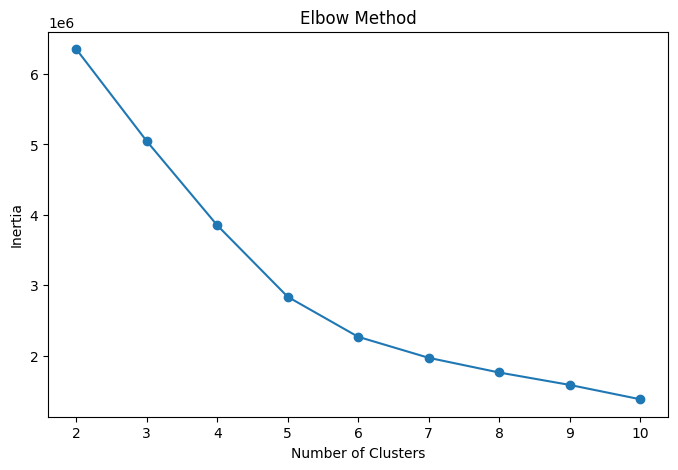

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values, #x-axis
    inertia,#y-axis
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [18]:
feature_columns = [
    "total_interactions",
    "total_views",
    "total_cart",
    "total_transactions",
    "unique_items",
    "avg_interaction_strength",
    "recency_days"
]

In [17]:
customer_features.columns

Index(['visitorid', 'total_interactions', 'total_views', 'total_cart',
       'total_transactions', 'unique_items', 'avg_interaction_strength',
       'recency_days'],
      dtype='object')

## Silhouette Analysis

Evaluate clustering quality for different values of K.

In [ ]:
sample_df = customer_features.head(10000)

X_sample = scaler.fit_transform(
    sample_df[feature_columns]
)

In [ ]:
scores = []

for k in range(5,6,7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_sample)

    score = silhouette_score(
        X_sample,
        labels
    )

    scores.append(score)

    print(
        f"K={k}, Silhouette Score={score:.4f}"
    )